# Sentiment Analysis with RNN, LSTM, and GRU
---

## About the Dataset

The **IMDB Movie Review Dataset** contains 50,000 movie reviews from IMDb:

- 25,000 training reviews, 25,000 test reviews
- Balanced classes: 50% positive, 50% negative
- Reviews vary widely in length: some are 10 words, some exceed 2,000 words

## Imports

In [ ]:
import torch
import numpy as np
import pandas as pd
import time

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())

PyTorch version : 2.11.0+cu128
CUDA available  : True


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Load Dataset

In [ ]:
df = pd.read_csv('IMDB Dataset.csv', engine='python')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Convert labels to binary
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Label distribution:')
print(df['label'].value_counts())

Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


## Explore Review Lengths

Min length  : 4
Max length  : 2470
Mean length : 231
Median      : 173
Reviews > 500 words: 3903 (7.8%)


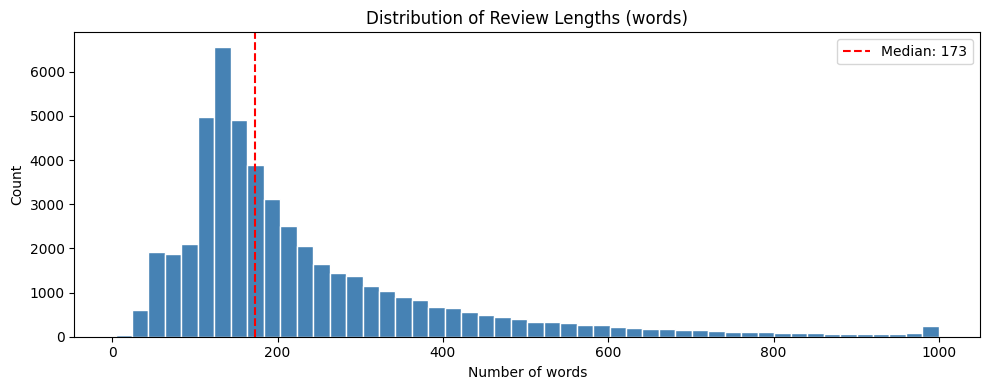

In [ ]:
import matplotlib.pyplot as plt

lengths = df['review'].apply(lambda x: len(x.split()))

print(f'Min length  : {lengths.min()}')
print(f'Max length  : {lengths.max()}')
print(f'Mean length : {lengths.mean():.0f}')
print(f'Median      : {lengths.median():.0f}')
print(f'Reviews > 500 words: {(lengths > 500).sum()} ({(lengths > 500).mean()*100:.1f}%)')

plt.figure(figsize=(10, 4))
plt.hist(lengths.clip(upper=1000), bins=50, color='steelblue', edgecolor='white')
plt.axvline(lengths.median(), color='red', linestyle='--',
            label=f'Median: {lengths.median():.0f}')
plt.title('Distribution of Review Lengths (words)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Text Preprocessing

In [ ]:
print(df['review'].iloc[0][:200])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo


In [ ]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)        # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # keep only letters
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)          # collapse whitespace
    return text

df['clean'] = df['review'].apply(clean_text)

In [ ]:
print(df['clean'].iloc[0][:200])

one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br


## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42,
                                      stratify=df['label'])
train_df, val_df  = train_test_split(train_df, test_size=0.1, random_state=42,
                                      stratify=train_df['label'])

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Train: 36000  Val: 4000  Test: 10000


## Build Vocabulary

In [ ]:
from collections import Counter

# Build vocabulary from training data only
counter = Counter()
for text in train_df['clean']:
    counter.update(text.split())

# Keep top 20,000 words
VOCAB_SIZE = 20000
most_common = counter.most_common(VOCAB_SIZE)
print(f'Vocabulary size: {len(most_common)}')
print(most_common[:10])

Vocabulary size: 20000
[('the', 481880), ('and', 233974), ('a', 233088), ('of', 208919), ('to', 193409), ('is', 151894), ('it', 137731), ('in', 134733), ('i', 127020), ('this', 108904)]


In [ ]:
# Reserve 0 for padding, 1 for unknown
word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size: {VOCAB_SIZE}')
print(word2idx)

Vocabulary size: 20002
{'<PAD>': 0, '<UNK>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7, 'it': 8, 'in': 9, 'i': 10, 'this': 11, 'that': 12, 's': 13, 'was': 14, 'as': 15, 'for': 16, 'movie': 17, 'with': 18, 'but': 19, 'film': 20, 'you': 21, 't': 22, 'on': 23, 'not': 24, 'he': 25, 'are': 26, 'his': 27, 'have': 28, 'one': 29, 'be': 30, 'all': 31, 'at': 32, 'they': 33, 'by': 34, 'an': 35, 'who': 36, 'so': 37, 'from': 38, 'like': 39, 'there': 40, 'or': 41, 'just': 42, 'her': 43, 'out': 44, 'if': 45, 'about': 46, 'has': 47, 'what': 48, 'some': 49, 'good': 50, 'can': 51, 'when': 52, 'more': 53, 'very': 54, 'she': 55, 'up': 56, 'no': 57, 'time': 58, 'even': 59, 'my': 60, 'would': 61, 'which': 62, 'story': 63, 'really': 64, 'only': 65, 'see': 66, 'their': 67, 'had': 68, 'me': 69, 'well': 70, 'were': 71, 'we': 72, 'much': 73, 'than': 74, 'bad': 75, 'other': 76, 'get': 77, 'do': 78, 'been': 79, 'people': 80, 'will': 81, 'also': 82, 'great': 83, 'into': 84, 'him': 85, 'because': 86, 

## Encode and Pad Sequences

In [ ]:
MAX_LEN = 300

def encode(text, word2idx, max_len):
    tokens = text.split()
    ids    = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    # Truncate
    ids = ids[:max_len]
    # Pad
    ids = ids + [0] * (max_len - len(ids))
    return ids


def encode_df(df, word2idx, max_len):
    X = np.array([encode(t, word2idx, max_len) for t in df['clean']])
    y = df['label'].values
    return X, y

In [ ]:
X_train, y_train = encode_df(train_df, word2idx, MAX_LEN)
X_val,   y_val   = encode_df(val_df,   word2idx, MAX_LEN)
X_test,  y_test  = encode_df(test_df,  word2idx, MAX_LEN)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape  : {X_val.shape}')
print(f'X_test shape : {X_test.shape}')

X_train shape: (36000, 300)
X_val shape  : (4000, 300)
X_test shape : (10000, 300)


In [ ]:
print(X_train[0])
print(train_df['clean'].iloc[0])

[    2    17   528   123    15    72    66     4   840     5     4   634
 18392   145     9     2    13     9   835    94     4   333    63     7
   591    46     4   954   254  5865     1    36    91     4   777    18
  3100     6    77    50  8112     1  2649   186   335     6   159     9
    27  3962   521    93     3   326    15  7603    25    82  4371     2
  1465    18    67   527    49    58   101  1477   215     6  2002    85
    29     5    93   217   317    34     1   160    29  1150     2  5865
   308   101    12     2   999   249     7   591     3    49   216   764
  1825     7   554    12    25    47    35   161  3195   314    15  9982
    25  1069     6   141    40    18    49   349     6    66    48    13
    56   121   118  1825   119    12     2   357   306     7     2 19088
   306    15    16    69    11    17    68     4    50    63    16     4
   180   482    19   351   327     3   336   309   286    42  2433     8
   450  8112     7     4   405   462     5  2827   

## Create DataLoaders

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

def make_loader(X, y, batch_size, shuffle):
    X_t = torch.tensor(X, dtype=torch.long)
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size, shuffle=shuffle)

In [ ]:
BATCH_SIZE = 64

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Train batches: 563
Val batches  : 63
Test batches : 157


In [ ]:
print(next(iter(train_loader)))

[tensor([[ 1829,  5379,    47,  ...,     0,     0,     0],
        [    4,  4049,     1,  ...,     0,     0,     0],
        [   42,    35,   526,  ...,     0,     0,     0],
        ...,
        [  136, 11776,  4866,  ...,     0,     0,     0],
        [ 7373,  7467,     1,  ...,     0,     0,     0],
        [   10,    28,    42,  ...,     0,     0,     0]]), tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.,
        1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1.,
        0., 1., 1., 1., 1., 0., 1., 0., 1., 1.])]


---
## Vanilla RNN (Baseline)

We start with vanilla RNN to establish a baseline and demonstrate its limitations on long reviews.

**Expected behavior:** Accuracy will plateau around 50-60%. The model struggles because long IMDB reviews contain dependencies that span hundreds of words. Vanilla RNN cannot carry context that far due to the vanishing gradient problem.

---

In [ ]:
import torch.nn as nn

class VanillaRNN(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0) #  lookup table (20,000 × 100)

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x)) # (batch, seq_len, embed_dim)
        output, hidden = self.rnn(embedded) # hidden: (num_layers, batch, hidden)
        # Use last layer hidden state
        last_hidden = self.dropout(hidden[-1]) # (batch, hidden)
        logits = self.fc(last_hidden) # (batch, 1) — one score per review
        logits = logits.squeeze(1) # (batch,)   — remove the extra dimension
        return logits

## Training and Evaluation Functions

In [ ]:
import torch.optim as optim

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
        optimizer.step()

        total_loss += loss.item()
        preds    = (torch.sigmoid(output) >= 0.5).long()
        correct += (preds == y_batch.long()).sum().item()
        total   += y_batch.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output  = model(X_batch)
            loss    = criterion(output, y_batch)
            total_loss += loss.item()
            preds    = (torch.sigmoid(output) >= 0.5).long()
            correct += (preds == y_batch.long()).sum().item()
            total   += y_batch.size(0)

    return total_loss / len(loader), correct / total


def train_model(model, train_loader, val_loader, epochs, lr, device,
                model_name='model'):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start   = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer,
                                       criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        print(f'[{model_name}] Epoch {epoch:02d}/{epochs}  '
              f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
              f'Val Loss: {va_loss:.4f}  Val Acc: {va_acc:.4f}')

    elapsed = time.time() - start
    print(f'\nTraining time: {elapsed/60:.1f} minutes')
    return history, elapsed

## Train Vanilla RNN

In [ ]:
# Hyperparameters
EMBED_DIM   = 100
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
EPOCHS      = 10
LR          = 0.001

rnn_model = VanillaRNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(rnn_model)
print(f'\nParameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

VanillaRNN(
  (embedding): Embedding(20002, 100, padding_idx=0)
  (rnn): RNN(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Parameters: 2,062,793


In [ ]:
rnn_history, rnn_time = train_model(
    rnn_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    model_name='RNN'
)

[RNN] Epoch 01/10  Train Loss: 0.6956  Train Acc: 0.4976  Val Loss: 0.6929  Val Acc: 0.5045
[RNN] Epoch 02/10  Train Loss: 0.6933  Train Acc: 0.5091  Val Loss: 0.7011  Val Acc: 0.5068
[RNN] Epoch 03/10  Train Loss: 0.6938  Train Acc: 0.5101  Val Loss: 0.6990  Val Acc: 0.4993
[RNN] Epoch 04/10  Train Loss: 0.6954  Train Acc: 0.5058  Val Loss: 0.6958  Val Acc: 0.4910
[RNN] Epoch 05/10  Train Loss: 0.6959  Train Acc: 0.5036  Val Loss: 0.6939  Val Acc: 0.5032
[RNN] Epoch 06/10  Train Loss: 0.6953  Train Acc: 0.5018  Val Loss: 0.6949  Val Acc: 0.5038
[RNN] Epoch 07/10  Train Loss: 0.6955  Train Acc: 0.5061  Val Loss: 0.6956  Val Acc: 0.4895
[RNN] Epoch 08/10  Train Loss: 0.6951  Train Acc: 0.5008  Val Loss: 0.6929  Val Acc: 0.5082
[RNN] Epoch 09/10  Train Loss: 0.6955  Train Acc: 0.5002  Val Loss: 0.6949  Val Acc: 0.4890
[RNN] Epoch 10/10  Train Loss: 0.6948  Train Acc: 0.5031  Val Loss: 0.6950  Val Acc: 0.5008

Training time: 0.6 minutes


In [ ]:
# Evaluate on test set
criterion = nn.BCEWithLogitsLoss()
_, rnn_test_acc = evaluate(rnn_model, test_loader, criterion, device)
print(f'RNN Test Accuracy: {rnn_test_acc:.4f} ({rnn_test_acc*100:.2f}%)')

RNN Test Accuracy: 0.5164 (51.64%)


## Why Vanilla RNN Struggles

The accuracy numbers above confirm what Class 22 theory predicted:

- The vanishing gradient problem prevents the model from learning dependencies across hundreds of words
- The hidden state at the end of a 300-word review contains almost no information about words from the beginning
- The model essentially classifies based on the last few words, missing most of the context
- Reviews with complex sentiment ("despite X, still Y") are particularly hard because the conclusion contradicts the opening

**Next:** LSTM with its cell state and gating mechanism directly addresses this.

---
## LSTM

LSTM introduces a separate cell state that carries information across many time steps via additive updates. The forget, input, and output gates control what gets stored, written, and read.

---

In [ ]:
class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers,
                 dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        # Use last layer hidden state
        last_hidden = self.dropout(hidden[-1])
        return self.fc(last_hidden).squeeze(1)

In [ ]:
lstm_model = LSTMModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(f'Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

lstm_history, lstm_time = train_model(
    lstm_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    model_name='LSTM'
)

Parameters: 2,250,185
[LSTM] Epoch 01/10  Train Loss: 0.6932  Train Acc: 0.5053  Val Loss: 0.6922  Val Acc: 0.5092
[LSTM] Epoch 02/10  Train Loss: 0.6942  Train Acc: 0.5120  Val Loss: 0.6846  Val Acc: 0.5780
[LSTM] Epoch 03/10  Train Loss: 0.6893  Train Acc: 0.5328  Val Loss: 0.6797  Val Acc: 0.5873
[LSTM] Epoch 04/10  Train Loss: 0.6734  Train Acc: 0.5836  Val Loss: 0.6667  Val Acc: 0.6150
[LSTM] Epoch 05/10  Train Loss: 0.6272  Train Acc: 0.6644  Val Loss: 0.6154  Val Acc: 0.6755
[LSTM] Epoch 06/10  Train Loss: 0.5575  Train Acc: 0.7314  Val Loss: 0.6335  Val Acc: 0.6753
[LSTM] Epoch 07/10  Train Loss: 0.4912  Train Acc: 0.7780  Val Loss: 0.4179  Val Acc: 0.8190
[LSTM] Epoch 08/10  Train Loss: 0.4291  Train Acc: 0.8157  Val Loss: 0.3855  Val Acc: 0.8438
[LSTM] Epoch 09/10  Train Loss: 0.3842  Train Acc: 0.8379  Val Loss: 0.3517  Val Acc: 0.8532
[LSTM] Epoch 10/10  Train Loss: 0.3604  Train Acc: 0.8525  Val Loss: 0.3337  Val Acc: 0.8698

Training time: 1.7 minutes


In [ ]:
_, lstm_test_acc = evaluate(lstm_model, test_loader, criterion, device)
print(f'LSTM Test Accuracy: {lstm_test_acc:.4f} ({lstm_test_acc*100:.2f}%)')

LSTM Test Accuracy: 0.8549 (85.49%)


---
## GRU

GRU simplifies LSTM by merging the cell state and hidden state into one vector and reducing from four gates to two. Fewer parameters, faster training, comparable accuracy.

---

In [ ]:
class GRUModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers,
                 dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                       padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded)
        last_hidden = self.dropout(hidden[-1])
        return self.fc(last_hidden).squeeze(1)

In [ ]:
gru_model = GRUModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(f'Parameters: {sum(p.numel() for p in gru_model.parameters()):,}')

gru_history, gru_time = train_model(
    gru_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    model_name='GRU'
)

Parameters: 2,187,721
[GRU] Epoch 01/10  Train Loss: 0.6933  Train Acc: 0.5068  Val Loss: 0.6917  Val Acc: 0.5165
[GRU] Epoch 02/10  Train Loss: 0.6925  Train Acc: 0.5152  Val Loss: 0.6908  Val Acc: 0.5222
[GRU] Epoch 03/10  Train Loss: 0.5417  Train Acc: 0.7046  Val Loss: 0.3590  Val Acc: 0.8480
[GRU] Epoch 04/10  Train Loss: 0.3084  Train Acc: 0.8698  Val Loss: 0.2735  Val Acc: 0.8865
[GRU] Epoch 05/10  Train Loss: 0.2495  Train Acc: 0.8983  Val Loss: 0.2626  Val Acc: 0.8900
[GRU] Epoch 06/10  Train Loss: 0.2090  Train Acc: 0.9180  Val Loss: 0.2696  Val Acc: 0.8942
[GRU] Epoch 07/10  Train Loss: 0.1849  Train Acc: 0.9286  Val Loss: 0.2566  Val Acc: 0.8940
[GRU] Epoch 08/10  Train Loss: 0.1621  Train Acc: 0.9378  Val Loss: 0.2468  Val Acc: 0.9008
[GRU] Epoch 09/10  Train Loss: 0.1436  Train Acc: 0.9462  Val Loss: 0.2885  Val Acc: 0.8985
[GRU] Epoch 10/10  Train Loss: 0.1285  Train Acc: 0.9519  Val Loss: 0.3123  Val Acc: 0.8928

Training time: 1.2 minutes


In [ ]:
_, gru_test_acc = evaluate(gru_model, test_loader, criterion, device)
print(f'GRU Test Accuracy: {gru_test_acc:.4f} ({gru_test_acc*100:.2f}%)')

GRU Test Accuracy: 0.8982 (89.82%)


---
## Comparison

---

In [ ]:
# Comparison table
rnn_params  = sum(p.numel() for p in rnn_model.parameters())
lstm_params = sum(p.numel() for p in lstm_model.parameters())
gru_params  = sum(p.numel() for p in gru_model.parameters())

comparison = pd.DataFrame({
    'Model'      : ['Vanilla RNN', 'LSTM', 'GRU'],
    'Parameters' : [f'{rnn_params:,}', f'{lstm_params:,}', f'{gru_params:,}'],
    'Test Acc'   : [f'{rnn_test_acc*100:.2f}%',
                    f'{lstm_test_acc*100:.2f}%',
                    f'{gru_test_acc*100:.2f}%'],
    'Train Time' : [f'{rnn_time/60:.1f} min',
                    f'{lstm_time/60:.1f} min',
                    f'{gru_time/60:.1f} min'],
    'Best Val Acc': [f'{max(rnn_history["val_acc"])*100:.2f}%',
                     f'{max(lstm_history["val_acc"])*100:.2f}%',
                     f'{max(gru_history["val_acc"])*100:.2f}%']
})

print(comparison.to_string(index=False))

      Model Parameters Test Acc Train Time Best Val Acc
Vanilla RNN  2,062,793   51.64%    0.6 min       50.82%
       LSTM  2,250,185   85.49%    1.7 min       86.98%
        GRU  2,187,721   89.82%    1.2 min       90.08%


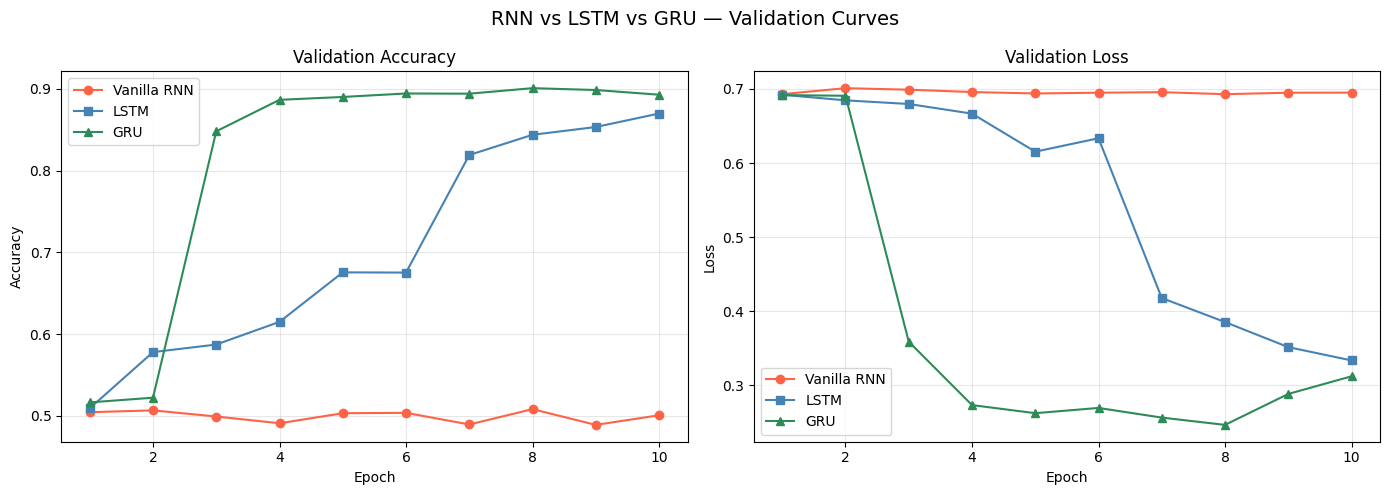

In [ ]:
# Combined validation accuracy curves
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_range, rnn_history['val_acc'],
             marker='o', label='Vanilla RNN', color='tomato')
axes[0].plot(epochs_range, lstm_history['val_acc'],
             marker='s', label='LSTM', color='steelblue')
axes[0].plot(epochs_range, gru_history['val_acc'],
             marker='^', label='GRU', color='seagreen')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_range, rnn_history['val_loss'],
             marker='o', label='Vanilla RNN', color='tomato')
axes[1].plot(epochs_range, lstm_history['val_loss'],
             marker='s', label='LSTM', color='steelblue')
axes[1].plot(epochs_range, gru_history['val_loss'],
             marker='^', label='GRU', color='seagreen')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RNN vs LSTM vs GRU — Validation Curves', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Sample predictions
def predict_sentiment(model, text, word2idx, max_len, device):
    model.eval()
    clean = clean_text(text)
    ids   = encode(clean, word2idx, max_len)
    x     = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    label = 'POSITIVE' if prob >= 0.5 else 'NEGATIVE'
    return label, prob


samples = [
    "This movie was absolutely incredible. The acting was superb and the story kept me engaged throughout.",
    "Terrible film. Boring, predictable, and a complete waste of two hours.",
    "Despite the slow start and confusing plot, the film redeemed itself with a stunning finale.",
    "One of the worst movies I have ever seen. The director had no idea what he was doing."
]

print(f'{"Review":<70} {"LSTM":>12} {"GRU":>12}')
print('-' * 96)
for review in samples:
    lstm_label, lstm_prob = predict_sentiment(lstm_model, review, word2idx,
                                               MAX_LEN, device)
    gru_label,  gru_prob  = predict_sentiment(gru_model,  review, word2idx,
                                               MAX_LEN, device)
    print(f'{review[:68]:<70} '
          f'{lstm_label}({lstm_prob:.2f}) '
          f'{gru_label}({gru_prob:.2f})')

Review                                                                         LSTM          GRU
------------------------------------------------------------------------------------------------
This movie was absolutely incredible. The acting was superb and the    POSITIVE(0.77) POSITIVE(1.00)
Terrible film. Boring, predictable, and a complete waste of two hour   NEGATIVE(0.04) NEGATIVE(0.00)
Despite the slow start and confusing plot, the film redeemed itself    NEGATIVE(0.16) NEGATIVE(0.15)
One of the worst movies I have ever seen. The director had no idea w   NEGATIVE(0.13) NEGATIVE(0.00)


---
## Pretrained GloVe Embeddings

So far all three models learned word embeddings from scratch. The embedding layer had no prior knowledge of what words mean.

**GloVe (Global Vectors for Word Representation)** embeddings were trained on 6 billion tokens from Wikipedia and news articles. Words with similar meanings have similar vectors. "Good" and "great" are close. "Good" and "terrible" are far apart.

Loading these pretrained vectors gives the model a head start: it already knows semantic relationships before seeing a single IMDB review.

---

In [ ]:
# Load GloVe 100d embeddings
GLOVE_PATH = '/content/glove.6B.100d.txt'

glove = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove[word] = vec

print(f'GloVe vectors loaded: {len(glove):,}')
print(f'Embedding dimension : {len(next(iter(glove.values())))}')

GloVe vectors loaded: 17,117
Embedding dimension : 100


In [ ]:
# Build embedding matrix
# Shape: (vocab_size, embed_dim)
# Words not found in GloVe get random initialization

embed_matrix = np.random.uniform(-0.1, 0.1, (VOCAB_SIZE, EMBED_DIM))
embed_matrix[0] = 0   # <PAD> stays zero

found = 0
for word, idx in word2idx.items():
    if word in glove:
        embed_matrix[idx] = glove[word]
        found += 1

print(f'Words found in GloVe: {found:,} / {VOCAB_SIZE:,} '
      f'({found/VOCAB_SIZE*100:.1f}%)')

Words found in GloVe: 11,096 / 20,002 (55.5%)


In [ ]:
class LSTMGloVe(nn.Module):

    def __init__(self, embed_matrix, hidden_size, num_layers,
                 dropout=0.3, pad_idx=0, freeze_embeddings=False):
        super().__init__()
        vocab_size, embed_dim = embed_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                       padding_idx=pad_idx)
        # Load pretrained weights
        self.embedding.weight.data.copy_(
            torch.tensor(embed_matrix, dtype=torch.float32)
        )
        # Optionally freeze — keep pretrained weights fixed
        self.embedding.weight.requires_grad = not freeze_embeddings

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        last_hidden = self.dropout(hidden[-1])
        return self.fc(last_hidden).squeeze(1)

In [ ]:
# Train LSTM with GloVe embeddings (fine-tuned)
lstm_glove_model = LSTMGloVe(
    embed_matrix=embed_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    freeze_embeddings=False   # allow fine-tuning
).to(device)

print(f'Parameters: {sum(p.numel() for p in lstm_glove_model.parameters()):,}')

glove_history, glove_time = train_model(
    lstm_glove_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    model_name='LSTM+GloVe'
)

Parameters: 2,250,185
[LSTM+GloVe] Epoch 01/10  Train Loss: 0.6921  Train Acc: 0.5080  Val Loss: 0.6926  Val Acc: 0.4993
[LSTM+GloVe] Epoch 02/10  Train Loss: 0.6844  Train Acc: 0.5258  Val Loss: 0.6583  Val Acc: 0.5650
[LSTM+GloVe] Epoch 03/10  Train Loss: 0.4881  Train Acc: 0.7781  Val Loss: 0.4409  Val Acc: 0.7155
[LSTM+GloVe] Epoch 04/10  Train Loss: 0.3589  Train Acc: 0.8535  Val Loss: 0.3913  Val Acc: 0.8498
[LSTM+GloVe] Epoch 05/10  Train Loss: 0.3244  Train Acc: 0.8742  Val Loss: 0.3634  Val Acc: 0.8748
[LSTM+GloVe] Epoch 06/10  Train Loss: 0.2720  Train Acc: 0.8982  Val Loss: 0.3022  Val Acc: 0.8845
[LSTM+GloVe] Epoch 07/10  Train Loss: 0.2053  Train Acc: 0.9259  Val Loss: 0.2907  Val Acc: 0.8895
[LSTM+GloVe] Epoch 08/10  Train Loss: 0.1661  Train Acc: 0.9404  Val Loss: 0.3085  Val Acc: 0.8902
[LSTM+GloVe] Epoch 09/10  Train Loss: 0.1392  Train Acc: 0.9529  Val Loss: 0.3160  Val Acc: 0.8900
[LSTM+GloVe] Epoch 10/10  Train Loss: 0.1141  Train Acc: 0.9641  Val Loss: 0.3486  Val 

In [ ]:
_, glove_test_acc = evaluate(lstm_glove_model, test_loader, criterion, device)
print(f'LSTM + GloVe Test Accuracy: {glove_test_acc:.4f} ({glove_test_acc*100:.2f}%)')

LSTM + GloVe Test Accuracy: 0.8920 (89.20%)


In [ ]:
# Final comparison: all four models
glove_params = sum(p.numel() for p in lstm_glove_model.parameters())

final_comparison = pd.DataFrame({
    'Model'       : ['Vanilla RNN', 'LSTM', 'GRU', 'LSTM + GloVe'],
    'Embedding'   : ['Learned', 'Learned', 'Learned', 'Pretrained (GloVe 6B)'],
    'Parameters'  : [f'{rnn_params:,}', f'{lstm_params:,}',
                     f'{gru_params:,}', f'{glove_params:,}'],
    'Test Acc'    : [f'{rnn_test_acc*100:.2f}%',
                     f'{lstm_test_acc*100:.2f}%',
                     f'{gru_test_acc*100:.2f}%',
                     f'{glove_test_acc*100:.2f}%'],
    'Train Time'  : [f'{rnn_time/60:.1f} min',
                     f'{lstm_time/60:.1f} min',
                     f'{gru_time/60:.1f} min',
                     f'{glove_time/60:.1f} min']
})

print('\nFinal Comparison:')
print(final_comparison.to_string(index=False))


Final Comparison:
       Model             Embedding Parameters Test Acc Train Time
 Vanilla RNN               Learned  2,062,793   51.64%    0.6 min
        LSTM               Learned  2,250,185   85.49%    1.7 min
         GRU               Learned  2,187,721   89.82%    1.2 min
LSTM + GloVe Pretrained (GloVe 6B)  2,250,185   89.20%    1.8 min


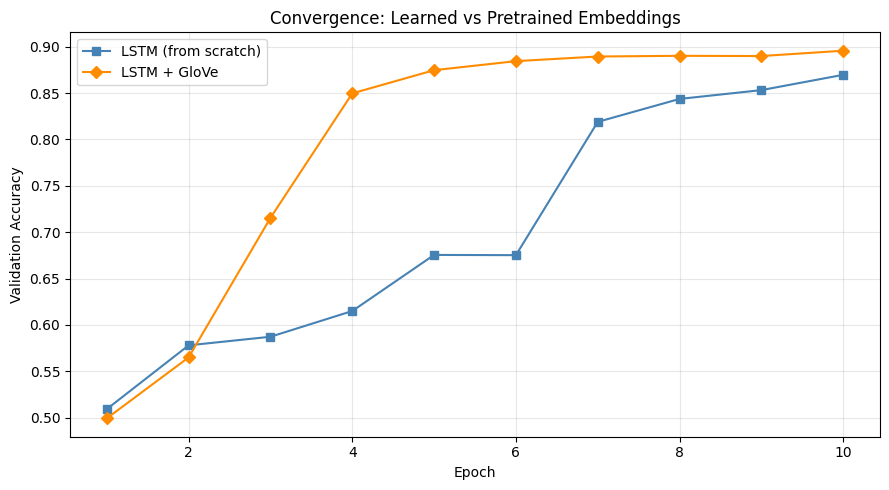

In [ ]:
# Convergence speed comparison: trained from scratch vs GloVe
plt.figure(figsize=(9, 5))
plt.plot(epochs_range, lstm_history['val_acc'],
         marker='s', label='LSTM (from scratch)', color='steelblue')
plt.plot(epochs_range, glove_history['val_acc'],
         marker='D', label='LSTM + GloVe', color='darkorange')
plt.title('Convergence: Learned vs Pretrained Embeddings')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Save the Model Weights
import os

os.makedirs('artifacts', exist_ok=True)

# Save only the weights (state_dict), not the full model.
# This is safer and works across PyTorch versions.
torch.save(gru_model.state_dict(), 'artifacts/gru_model.pt')
print('Model weights saved.')

Model weights saved.


In [ ]:
# Step 2: Save the Vocabulary
import json

with open('artifacts/word2idx.json', 'w') as f:
    json.dump(word2idx, f)
print(f'Vocabulary saved: {len(word2idx)} words.')

Vocabulary saved: 20002 words.


In [ ]:
# Step 3: Save the Config
config = {
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'max_len': MAX_LEN
}

with open('artifacts/config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Config saved:', config)

Config saved: {'vocab_size': 20002, 'embed_dim': 100, 'hidden_size': 128, 'num_layers': 2, 'max_len': 300}


In [ ]:
# Step 4: Verify the Saved Files
import os, json

for fname in ['gru_model.pt', 'word2idx.json', 'config.json']:
    path = f'artifacts/{fname}'
    size = os.path.getsize(path)
    print(f'{fname:20s} {size:>10,} bytes')

# Quick sanity check on config
with open('artifacts/config.json') as f:
    print('\nConfig:', json.load(f))

gru_model.pt          8,754,033 bytes
word2idx.json           348,527 bytes
config.json                 104 bytes

Config: {'vocab_size': 20002, 'embed_dim': 100, 'hidden_size': 128, 'num_layers': 2, 'max_len': 300}


In [ ]:
from google.colab import files
files.download('artifacts/gru_model.pt')
files.download('artifacts/word2idx.json')
files.download('artifacts/config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>